In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10

(x_train, _), (x_test, _) = cifar10.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"train data shape: {x_train.shape}")
print(f"test  data shape: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Размер тренировочных данных: (50000, 32, 32, 3, 1)
Размер тестовых данных: (10000, 32, 32, 3, 1)


In [ ]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * np.random.normal(
        loc=0.0, scale=1.0, size=images.shape
    )
    noisy = np.clip(noisy, 0., 1.)
    return noisy

noise_factor = 0.5 # !!!
x_train_noisy = add_noise(x_train, noise_factor)
x_test_noisy = add_noise(x_test, noise_factor)

In [ ]:
def build_autoencoder(input_shape=(32, 32, 3)):
    # enc
    encoder_input = keras.Input(shape=input_shape, name='original_img')

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # dec
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    # full model
    autoencoder = keras.Model(encoder_input, decoder_output, name='autoencoder')

    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ original_img (InputLayer)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,929 (113.00 KB)

 Trainable params: 28,929 (113.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 159s 399ms/step - loss: 0.0262 - val_loss: 0.0171
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 152s 390ms/step - loss: 0.0169 - val_loss: 0.0163
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 404ms/step - loss: 0.0163 - val_loss: 0.0158
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 201s 402ms/step - loss: 0.0157 - val_loss: 0.0155
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 153s 392ms/step - loss: 0.0156 - val_loss: 0.0153
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 153s 391ms/step - loss: 0.0153 - val_loss: 0.0152
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 157s 402ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 396ms/step - loss: 0.0151 - val_loss: 0.0151
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 204s 402ms/step - loss: 0.0150 - val_loss: 0.0150
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 195s 385ms/step - loss: 0.0149 - val_loss: 0.0148
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 155s 396ms/step - loss: 0.0148 - val_loss: 0.0148
Epoch 12

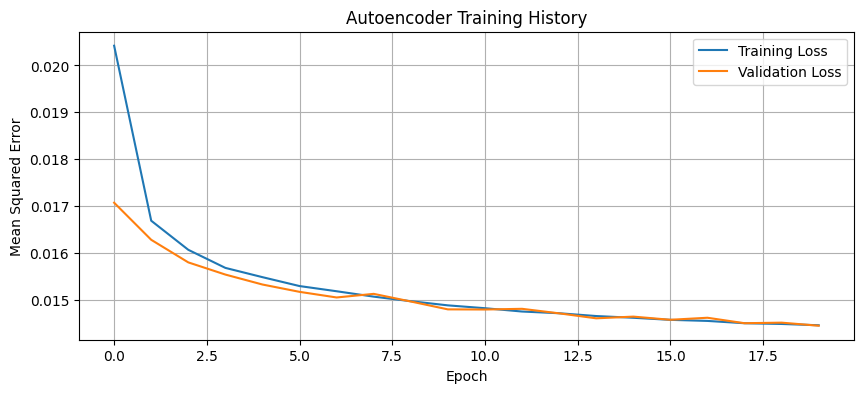

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


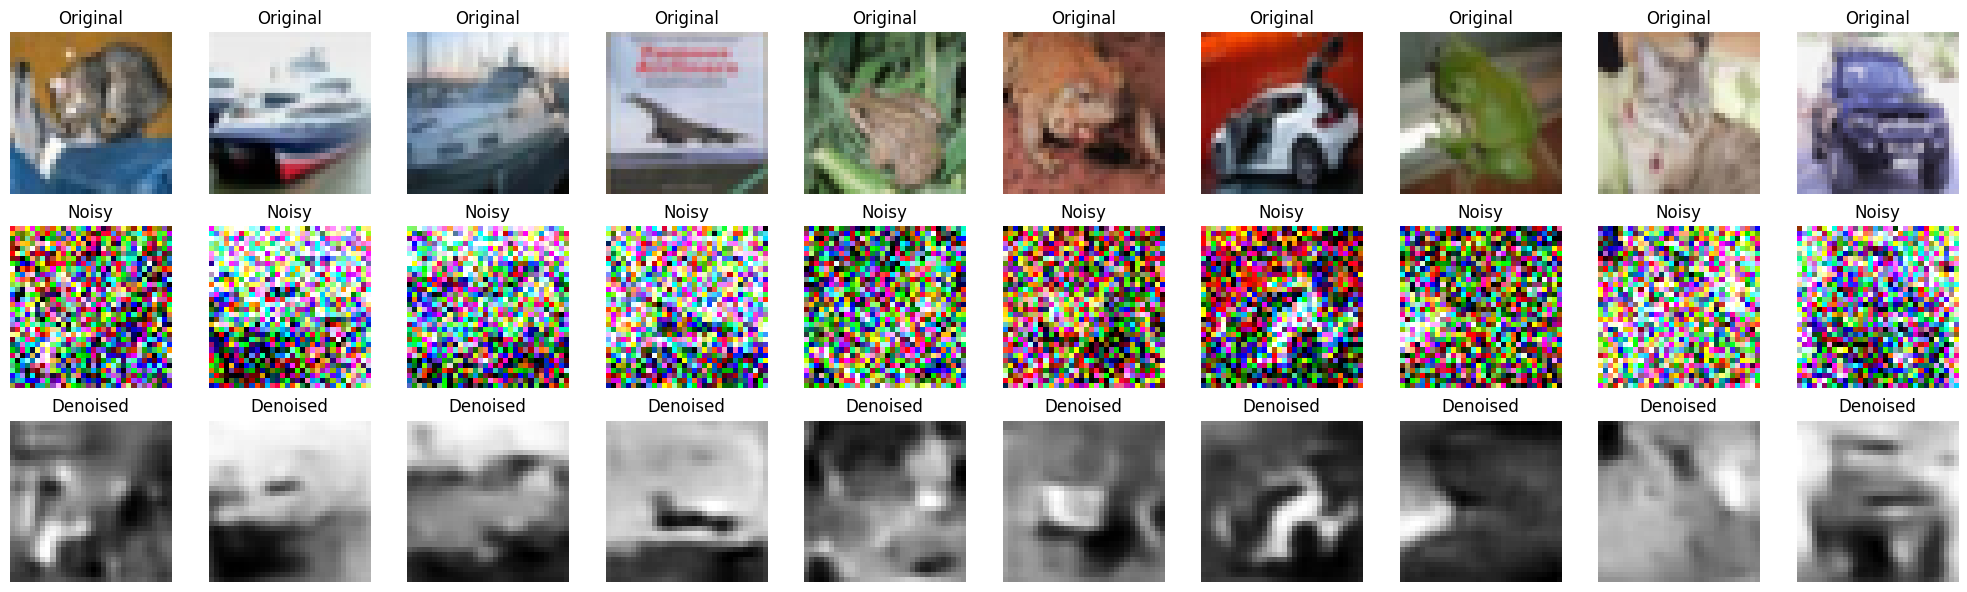

In [ ]:
def visualize_results(original, noisy, denoised, num_images=10):
    plt.figure(figsize=(20, 6))

    for i in range(num_images):
        # orig
        ax = plt.subplot(3, num_images, i + 1)
        plt.imshow(original[i].squeeze(), cmap='gray')
        plt.title("Original")
        plt.axis('off')

        # noise
        ax = plt.subplot(3, num_images, i + 1 + num_images)
        plt.imshow(noisy[i].squeeze(), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # out
        ax = plt.subplot(3, num_images, i + 1 + 2*num_images)
        plt.imshow(denoised[i].squeeze(), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

denoised_images = autoencoder.predict(x_test_noisy)

visualize_results(x_test, x_test_noisy, denoised_images, num_images=10)